## Introduction

### Import Data

In [ ]:
import polars as pl
from great_tables import GT
import math
import json
import urllib.request, io

# Convert clock strings ("MM:SS" / "M:SS") to total seconds.
# events.Clock uses zero-padded minutes ("09:30"); tracking "Game Clock" is unpadded ("9:30").
# Casting both to integer seconds makes them directly comparable for joins.
def clock_to_seconds(col):
    parts = pl.col(col).str.split(":")
    return (
        parts.list.get(0).cast(pl.Int64) * 60
        + parts.list.get(1).cast(pl.Int64)
    )

# Add the seconds column and slot it right after its source column.
def add_seconds_after(df, src, new):
    df = df.with_columns(clock_to_seconds(src).alias(new))
    cols = [c for c in df.columns if c != new]
    cols.insert(df.get_column_index(src) + 1, new)
    return df.select(cols)

# Every game is read directly from the Big Data Cup 2026 release (no local download).
# Each row is tagged with a "Game" id (the filename stem, e.g. "2025-10-11.Team.A.@.Team.D"),
# identical for a game's Events and Tracking files. That key is required downstream: the
# shots<->tracking joins match on Period + Frame, but Frame is only a per-game counter, so
# without "Game" they would cross-match rows between different games.
_RELEASE_API = "https://api.github.com/repos/bigdatacup/Big-Data-Cup-2026/releases/tags/Data"
_assets = {a["name"]: a["browser_download_url"]
           for a in json.load(urllib.request.urlopen(_RELEASE_API))["assets"]}

def _read_url(url, **kwargs):
    return pl.read_csv(io.BytesIO(urllib.request.urlopen(url).read()), **kwargs)

# Events: one file per game.
event_frames = []
for name, url in _assets.items():
    if not name.endswith(".Events.csv"):
        continue
    game = name[: -len(".Events.csv")]
    df = _read_url(url, schema_overrides={"Player_Id": pl.String, "Player_Id_2": pl.String})
    df = add_seconds_after(df, "Clock", "Clock_Seconds")
    df = df.with_columns(pl.lit(game).alias("Game"))
    event_frames.append(df)
events = pl.concat(event_frames)

# Tracking: P1/P2/P3 (+ POT overtime). ".Tracking_P" excludes Shifts and camera_orientations.
track_frames = []
for name, url in _assets.items():
    if ".Tracking_P" not in name:
        continue
    game = name.split(".Tracking_")[0]
    df = _read_url(url, schema_overrides={"Rink Location Z (Feet)": pl.Float64, "Period": pl.String}).drop("Player Id")
    # Overtime tracking labels Period as "OT"; events use 4 for OT. Normalize to 4 (Int64)
    # so the dtype is consistent across files and OT shots can join their tracking frames.
    df = df.with_columns(pl.col("Period").replace("OT", "4").cast(pl.Int64))
    df = add_seconds_after(df, "Game Clock", "Game_Clock_Seconds")
    df = df.with_columns(pl.lit(game).alias("Game"))
    track_frames.append(df)

# One table of every tracked player-frame across all games and periods.
tracking = pl.concat(track_frames)

### Distribution of Shot Types in the dataset

In [ ]:
shot_types = (
    events.filter(pl.col("Event").is_in(["Shot", "Goal"]))
    .group_by("Detail_1")
    .agg(pl.len().alias("count"))
    .with_columns((pl.col("count") / pl.col("count").sum()).alias("pct"))
    .sort("count", descending=True)
)

(
    GT(shot_types)
    .tab_header(title="Distribution of shot types in the dataset")
    .cols_label(Detail_1="Shot Type", pct="% of Shots")
    .fmt_percent("pct", decimals=1)
    .cols_hide("count")
    .cols_width({"Detail_1": "150px", "pct": "110px"})
)


#### Plot

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Create bar chart with percentages
ax.bar(shot_types["Detail_1"], shot_types["pct"] * 100, color="#1f77b4", edgecolor="black", alpha=0.7)

# Customize the plot
ax.set_xlabel("Shot Type", fontsize=12, fontweight="bold")
ax.set_ylabel("Percentage (%)", fontsize=12, fontweight="bold")
ax.set_title("Distribution of Shot Types (Percentage)", fontsize=14, fontweight="bold")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha="right")

# Add percentage labels on top of bars
for i, v in enumerate(shot_types["pct"]):
    ax.text(i, v * 100 + 1, f"{v*100:.1f}%", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

### Distribution of Shot Outcomes in the dataset

In [ ]:
descriptions = {
    "Saved": "The shot is on target and saved by the goaltender.",
    "Goal": "The shot is on target and not saved by the goaltender, resulting in a goal.",
    "Blocked": "The shot is blocked by a skater from the defending team.",
    "Missed": "The shot is not on target.",
}

shot_outcomes = (
    events.filter(pl.col("Event").is_in(["Shot", "Goal"]))
    .with_columns(
        pl.when(pl.col("Event") == "Goal")
        .then(pl.lit("Goal"))
        .when((pl.col("Event") == "Shot") & (pl.col("Detail_2") == "On Net"))
        .then(pl.lit("Saved"))
        .when((pl.col("Event") == "Shot") & (pl.col("Detail_2") == "Blocked"))
        .then(pl.lit("Blocked"))
        .when((pl.col("Event") == "Shot") & (pl.col("Detail_2") == "Missed"))
        .then(pl.lit("Missed"))
        .alias("Outcome")
    )
    .group_by("Outcome")
    .agg(pl.len().alias("count"))
    .with_columns((pl.col("count") / pl.col("count").sum()).alias("pct"))
    .with_columns(pl.col("Outcome").replace(descriptions).alias("Description"))
    .select("Outcome", "Description", "pct")
    .sort("pct", descending=True)
)

(
    GT(shot_outcomes)
    .tab_header(title="Distribution of shot outcomes in the dataset")
    .cols_label(
        Outcome="Shot Outcome",
        Description="Description",
        pct="% of Shots",
    )
    .fmt_percent("pct", decimals=1)
    .cols_width({"Outcome": "130px", "Description": "420px", "pct": "110px"})
)


### Feature-Based Expected Goals Model

#### Visualize Shot Location

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Arc, Circle, FancyBboxPatch

# Prepare shot data with outcome labels, normalized coordinates, and shot angle
shot_data = (
    events
    .filter(
        pl.col("Event").is_in(["Shot", "Goal"]),
        pl.col("Period") == 1,
    )
    .with_columns(
        pl.when(pl.col("Event") == "Goal")
        .then(pl.lit("Goal"))
        .when((pl.col("Event") == "Shot") & (pl.col("Detail_2") == "On Net"))
        .then(pl.lit("Saved"))
        .when((pl.col("Event") == "Shot") & (pl.col("Detail_2") == "Blocked"))
        .then(pl.lit("Blocked"))
        .when((pl.col("Event") == "Shot") & (pl.col("Detail_2") == "Missed"))
        .then(pl.lit("Missed"))
        .alias("Outcome")
    )
    # Normalize all shots to the right side
    .with_columns(
        pl.when(pl.col("X_Coordinate") < 0)
        .then(-pl.col("X_Coordinate"))
        .otherwise(pl.col("X_Coordinate"))
        .alias("X_Coordinate"),

        pl.when(pl.col("X_Coordinate") < 0)
        .then(-pl.col("Y_Coordinate"))
        .otherwise(pl.col("Y_Coordinate"))
        .alias("Y_Coordinate"),
    )
    # Compute shot angle: 0° = straight on, 90° = side of net
    .with_columns(
        (
            pl.arctan2(pl.col("Y_Coordinate"), 89 - pl.col("X_Coordinate"))
            .abs()
            * (180 / 3.141592653589793)
        ).alias("Shot_Angle")
    )
    .select("X_Coordinate", "Y_Coordinate", "Outcome", "Shot_Angle")
)

outcome_markers = {
    "Goal":    {"marker": "*", "size": 250},
    "Saved":   {"marker": "o", "size":  90},
    "Blocked": {"marker": "s", "size":  90},
    "Missed":  {"marker": "^", "size":  90},
}

cmap = plt.cm.plasma
angles = shot_data.get_column("Shot_Angle").to_list()
norm = mcolors.Normalize(vmin=min(angles), vmax=max(angles))

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor("#e8f4fb")

# --- Rink ---
ax.add_patch(FancyBboxPatch(
    (-100, -42.5), 200, 85,
    boxstyle="round,pad=0,rounding_size=28",
    linewidth=2, edgecolor="black", facecolor="white", zorder=1,
))
for x, color, lw in [(0, "#c0392b", 3.0), (25, "#2980b9", 3.0), (89, "#c0392b", 1.5)]:
    ax.plot([x, x], [-42.5, 42.5], color=color, linewidth=lw, zorder=2)
for y in [22, -22]:
    ax.add_patch(Circle((69, y), 15, fill=False, color="#c0392b", linewidth=1.5, zorder=2))
ax.add_patch(Arc((89, 0), 12, 12, theta1=270, theta2=90, color="#2980b9", linewidth=1.5, zorder=2))

# --- Plot shots: color = angle, shape = outcome ---
for outcome, style in outcome_markers.items():
    subset = shot_data.filter(pl.col("Outcome") == outcome)
    ax.scatter(
        subset.get_column("X_Coordinate").to_list(),
        subset.get_column("Y_Coordinate").to_list(),
        c=subset.get_column("Shot_Angle").to_list(),
        cmap=cmap, norm=norm,
        marker=style["marker"], s=style["size"],
        zorder=5, edgecolors="black", linewidths=0.5, alpha=0.9,
    )

# --- Colorbar ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("Shot Angle (°)", fontsize=11)

# --- Legend for shapes ---
handles = [
    plt.scatter([], [], marker=s["marker"], s=s["size"], c="gray",
                edgecolors="black", linewidths=0.5, label=o)
    for o, s in outcome_markers.items()
]
ax.legend(handles=handles, loc="upper left", fontsize=10, frameon=False, title="Outcome")

ax.set_xlim(0, 105)
ax.set_ylim(-47, 55)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Shot Locations — Period 1\nColor = Shot Angle, Shape = Outcome", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()


#### Shot Location

In [ ]:
shot_location = (
    events
    .filter(pl.col("Event").is_in(["Shot", "Goal"]))
    # Normalize to right side
    .with_columns(
        pl.when(pl.col("X_Coordinate") < 0)
        .then(-pl.col("X_Coordinate"))
        .otherwise(pl.col("X_Coordinate"))
        .alias("X_Coordinate"),

        pl.when(pl.col("X_Coordinate") < 0)
        .then(-pl.col("Y_Coordinate"))
        .otherwise(pl.col("Y_Coordinate"))
        .alias("Y_Coordinate"),
    )
    # Shot angle (degrees) and meridian distance
    .with_columns(
        (
            pl.arctan2(pl.col("Y_Coordinate"), 89 - pl.col("X_Coordinate"))
            .abs()
            * (180 / math.pi)
        ).alias("Shot_Angle"),
        pl.col("Y_Coordinate").abs().alias("d_m"),
    )
    # Distance via trigonometry: d = d_m / sin(θ), fallback to (89 - x) when Y = 0
    .with_columns(
        pl.when(pl.col("d_m") == 0)
        .then(89 - pl.col("X_Coordinate"))
        .otherwise(
            pl.col("d_m") / (pl.col("Shot_Angle") * math.pi / 180).sin()
        )
        .alias("d_trig"),
        # Euclidean distance as sanity check
        ((89 - pl.col("X_Coordinate")).pow(2) + pl.col("Y_Coordinate").pow(2))
        .sqrt()
        .alias("d_euclidean"),
    )
)



##### Notes
1. `Shot_Angle`: Shot angle (The angle of the shot)
2. `d_m`: Meridian distance (The distance between the shot location and the meridian)
3. `d_trig`/`d_euclidean`: Shot distance (The distance between the shot location and the goal)
    - `d_trig` and `d_euclidean` are equal. `d_euclidean` calculated as a sanity check

#### Shooter Motion

In [ ]:
# Goal: the shooter's *speed* (magnitude of velocity) at the instant they shot.
# Tracking gives position over time; events tell us who/when/where each shot was.
#
# Tracking runs at ~30 fps: the "Image Id" suffix is a per-period frame counter that
# ticks ~30 times per game-clock second (e.g. "..._066486" -> "..._066487"). Frames
# occasionally drop, so velocity uses the *actual* frame-index gap for dt, never an
# assumed constant. We smooth with a small central difference to damp tracking jitter.

FPS = 30                  # tracking frame rate (frames per second)
SMOOTH_K = 3              # central-difference half-window (~0.1 s each side)
FT_PER_S_TO_MPH = 0.6818  # 1 ft/s = 0.6818 mph
MAX_SPEED_MPH = 30.0      # human skaters peak ~25 mph; above this is a tracking glitch
MAX_SPEED_FPS = MAX_SPEED_MPH / FT_PER_S_TO_MPH

players = (
    tracking
    .filter(pl.col("Player or Puck") == "Player")
    .with_columns(
        # Numeric frame index from the Image Id suffix, and jersey as a string for matching.
        pl.col("Image Id").str.split("_").list.last().cast(pl.Int64).alias("Frame"),
        pl.col("Player Jersey Number").cast(pl.String).alias("Jersey"),
    )
    # Drop rows whose jersey couldn't be read: they'd all collapse into one bogus "null"
    # track, and differencing positions of *different* players invents huge fake speeds.
    .filter(pl.col("Jersey").is_not_null())
    # Order each player's frames in time so shift() walks consecutive samples.
    .sort(["Game", "Period", "Team", "Jersey", "Frame"])
    .with_columns(
        # Central difference over +/- SMOOTH_K frames, partitioned per player-period.
        (pl.col("Rink Location X (Feet)").shift(-SMOOTH_K) - pl.col("Rink Location X (Feet)").shift(SMOOTH_K))
            .over(["Game", "Period", "Team", "Jersey"]).alias("dx"),
        (pl.col("Rink Location Y (Feet)").shift(-SMOOTH_K) - pl.col("Rink Location Y (Feet)").shift(SMOOTH_K))
            .over(["Game", "Period", "Team", "Jersey"]).alias("dy"),
        (pl.col("Frame").shift(-SMOOTH_K) - pl.col("Frame").shift(SMOOTH_K))
            .over(["Game", "Period", "Team", "Jersey"]).alias("dframe"),
    )
    .with_columns(
        # dt = frames / fps (seconds); speed = displacement / dt, in feet per second.
        ((pl.col("dx") ** 2 + pl.col("dy") ** 2).sqrt() / (pl.col("dframe") / FPS)).alias("speed_fps")
    )
    .with_columns(
        # Null out physically impossible speeds (tracking ID-swaps / position jumps) so
        # they don't poison the per-shot pick or its fallback median.
        pl.when(pl.col("speed_fps") <= MAX_SPEED_FPS).then(pl.col("speed_fps")).otherwise(None).alias("speed_fps")
    )
    .with_columns(
        (pl.col("speed_fps") * FT_PER_S_TO_MPH).alias("speed_mph")
    )
)

# Peek at the players table
players.select(
    "Game", "Period", "Team", "Jersey", "Frame", "Game_Clock_Seconds",
    "Rink Location X (Feet)", "Rink Location Y (Feet)", "speed_fps", "speed_mph",
)

In [ ]:
# Match each Shot/Goal event to the tracking frame where the puck was released, then
# read the shooter's speed there.
#
# Matching keys: events Player_Id is a jersey number, but jerseys repeat across teams,
# so we match on Period + Team + Jersey. Event "Team" is a name (e.g. "Team A");
# tracking "Team" is Home/Away -> map via Home_Team/Away_Team.
#
# Pinning the release: the event stores the release X/Y. Within +/-1 game-clock second
# of the event we pick the shooter frame whose tracked position is closest to that
# release point. Event and tracking share the same rink frame here, but to be safe we
# also test the sign-flipped coords (-X,-Y) and keep whichever is closer.

shots = (
    events.filter(pl.col("Event").is_in(["Shot", "Goal"]))
    .with_columns(
        pl.when(pl.col("Team") == pl.col("Home_Team")).then(pl.lit("Home"))
          .otherwise(pl.lit("Away")).alias("Track_Team")
    )
    .with_row_index("shot_id")
)

# Candidate shooter frames: same player, within the event second (+/-1s), valid position.
cand = (
    shots.join(
        players.select([
            "Game", "Period", "Team", "Jersey", "Game_Clock_Seconds", "Frame",
            "Rink Location X (Feet)", "Rink Location Y (Feet)", "speed_fps",
        ]),
        left_on=["Game", "Period", "Track_Team", "Player_Id"],
        right_on=["Game", "Period", "Team", "Jersey"], how="left",
    )
    .filter((pl.col("Game_Clock_Seconds") - pl.col("Clock_Seconds")).abs() <= 1)
    .filter(pl.col("Rink Location X (Feet)").is_not_null()
            & pl.col("Rink Location Y (Feet)").is_not_null())
    .with_columns(
        ((pl.col("Rink Location X (Feet)") - pl.col("X_Coordinate")) ** 2
         + (pl.col("Rink Location Y (Feet)") - pl.col("Y_Coordinate")) ** 2).sqrt().alias("d_direct"),
        ((pl.col("Rink Location X (Feet)") + pl.col("X_Coordinate")) ** 2
         + (pl.col("Rink Location Y (Feet)") + pl.col("Y_Coordinate")) ** 2).sqrt().alias("d_flip"),
    )
    .with_columns(
        pl.min_horizontal("d_direct", "d_flip").alias("match_dist"),
        (pl.col("d_flip") < pl.col("d_direct")).alias("used_flip"),
    )
)

# Release frame = the candidate closest to the release point (nulls_last so a real
# match is never beaten by a missing distance).
release = (
    cand.sort("match_dist", nulls_last=True)
    .group_by("shot_id", maintain_order=True)
    .first()
    .select(["shot_id", "Frame", "match_dist", "used_flip", "speed_fps"])
)

# Fallback: representative speed over the whole event-second window.
window_med = cand.group_by("shot_id").agg(
    pl.col("speed_fps").median().alias("speed_fps_window_median"),
    pl.len().alias("n_candidates"),
)

# A match is trusted when the closest frame is within ~10 ft and has a defined speed;
# otherwise fall back to the window median (flagged), or mark no tracking at all.
MAX_MATCH_DIST = 10.0
shot_speeds = (
    shots.join(release, on="shot_id", how="left")
    .join(window_med, on="shot_id", how="left")
    .with_columns(
        pl.when((pl.col("match_dist") <= MAX_MATCH_DIST) & pl.col("speed_fps").is_not_null())
          .then(pl.col("speed_fps"))
          .otherwise(pl.col("speed_fps_window_median"))
          .alias("shooter_speed_fps"),
        pl.when((pl.col("match_dist") <= MAX_MATCH_DIST) & pl.col("speed_fps").is_not_null())
          .then(pl.lit("matched"))
          .when(pl.col("speed_fps_window_median").is_not_null())
          .then(pl.lit("fallback_window_median"))
          .otherwise(pl.lit("no_tracking"))
          .alias("match_quality"),
    )
    .with_columns((pl.col("shooter_speed_fps") * 0.6818).alias("shooter_speed_mph"))
    .sort(["Game", "Period", "Clock_Seconds"], descending=[False, False, True])
)

print(shot_speeds["match_quality"].value_counts())
shot_speeds.select(
    "Period", "Clock", "Team", "Player_Id", "Event", "Detail_1",
    "Frame", "match_dist", "used_flip", "shooter_speed_fps", "match_quality",
).head()


In [ ]:
# Shooter speed at the moment of each shot, in ft/s and mph.
shot_speed_table = shot_speeds.select(
    "Period", "Clock", "Team", "Player_Id", "Event", "Detail_1",
    "shooter_speed_fps", "shooter_speed_mph", "match_quality",
)

(
    GT(shot_speed_table)
    .tab_header(
        title="Shooter speed at the moment of the shot",
        subtitle="Magnitude of the shooter's velocity from tracking, pinned to the release frame",
    )
    .cols_label(
        Player_Id="Jersey",
        Detail_1="Shot Type",
        shooter_speed_fps="Speed (ft/s)",
        shooter_speed_mph="Speed (mph)",
        match_quality="Match",
    )
    .fmt_number(["shooter_speed_fps", "shooter_speed_mph"], decimals=1)
    .cols_width({
        "Period": "70px", "Clock": "70px", "Team": "90px", "Player_Id": "70px",
        "Event": "70px", "Detail_1": "110px",
        "shooter_speed_fps": "110px", "shooter_speed_mph": "110px", "match_quality": "150px",
    })
)


##### Notes
1. `shooter_speed_mph`/`shooter_speed_fps`: Shooter's speed in mph/fps (Shooter is defined as player closest to each shot)

#### Pressure

In [ ]:
# Pressure: distance from the shot location to the closest and second-closest
# *defending skater*. Following the cited paper, a continuous distance is more
# descriptive than counting defenders within 6 ft, and adding the second-closest
# defender captures pressure from multiple defenders.
#
# Goalies (jersey "Go") are excluded: a goalie sits in the crease on nearly every
# shot, so it would dominate the "closest defender" distance without reflecting
# real defensive pressure.
#
# We reuse the release Frame matched in the shooter-speed step: at that frame we take
# every opposing skater's tracked position and measure straight-line distance to the
# shot location. "used_flip" (from the same matching) tells us whether the event's
# (X, Y) had to be negated to line up with the tracking frame for that shot, so we
# apply the same flip to the shot coordinates here.
#
# Note: tracking coverage is partial -- many frames carry fewer than 5 skaters per team
# (see n_defenders). Coverage concentrates near the play, so the closest defenders (the
# ones this feature needs) are the most reliably tracked; n_defenders records how many
# defenders were actually visible at each shot's release frame.

# Defending skaters only: opposite tracking team, real jersey numbers, no goalies.
defenders = (
    players
    .filter(pl.col("Jersey") != "Go")
    .select([
        "Game", "Period", "Team", "Frame",
        "Rink Location X (Feet)", "Rink Location Y (Feet)",
    ])
)

# Per shot: the defending team, the release frame, and the shot location in tracking
# coordinates (negated when the release match used the flip).
shot_frames = (
    shots
    .join(release.select(["shot_id", "Frame", "used_flip"]), on="shot_id", how="left")
    .with_columns(
        pl.when(pl.col("Track_Team") == "Home").then(pl.lit("Away"))
          .otherwise(pl.lit("Home")).alias("Def_Team"),
        pl.when(pl.col("used_flip")).then(-pl.col("X_Coordinate"))
          .otherwise(pl.col("X_Coordinate")).alias("Shot_X"),
        pl.when(pl.col("used_flip")).then(-pl.col("Y_Coordinate"))
          .otherwise(pl.col("Y_Coordinate")).alias("Shot_Y"),
    )
    .select(["shot_id", "Game", "Period", "Def_Team", "Frame", "Shot_X", "Shot_Y"])
)

# Join each shot to every defending skater in its release frame; measure distance.
pressure = (
    shot_frames
    .join(
        defenders,
        left_on=["Game", "Period", "Def_Team", "Frame"],
        right_on=["Game", "Period", "Team", "Frame"],
        how="left",
    )
    .with_columns(
        ((pl.col("Rink Location X (Feet)") - pl.col("Shot_X")) ** 2
         + (pl.col("Rink Location Y (Feet)") - pl.col("Shot_Y")) ** 2)
        .sqrt().alias("def_dist")
    )
    .group_by("shot_id", maintain_order=True)
    .agg(
        pl.col("def_dist").sort(nulls_last=True).alias("def_dists"),
        pl.col("def_dist").is_not_null().sum().alias("n_defenders"),
    )
    .with_columns(
        pl.col("def_dists").list.get(0, null_on_oob=True).alias("closest_def_dist"),
        pl.col("def_dists").list.get(1, null_on_oob=True).alias("second_closest_def_dist"),
    )
    .drop("def_dists")
)

# Attach to the shots table for use as expected-goals model features.
shot_pressure = shots.join(pressure, on="shot_id", how="left").select(
    "Period", "Clock", "Team", "Player_Id", "Event", "Detail_1",
    "n_defenders", "closest_def_dist", "second_closest_def_dist",
)


pressure

##### Notes
1. `closest_def_dist`/`second_closest_def_dist`: Distance from shot location to closest and second closest defenders (Distance in feet)

#### Pre-Shot Movement

In [ ]:
# Pre-shot movement features, focused on lateral puck movement 
#
#   1. time_since_meridian  -- seconds since the puck last crossed the meridian
#   2. meridian_cross_dist  -- where it crossed, as distance to the goal line
#   3. avg_puck_speed       -- average puck speed in the 1 s before the shot
#
# The "meridian" is the Y = 0 line running net-to-net down the center of the ice; the
# puck crosses it when its Y coordinate changes sign (lateral / east-west movement,
# which forces the goalie across and raises shot danger). Features 1 and 2 are only
# defined when the crossing happened within 5 s before the shot.
#
# We reuse the per-shot release Frame and "used_flip" orientation matched in the
# shooter-speed step. Puck X/Y are normalized to attack-right (net at +89) using each
# shot's orientation so the goal-line distance is signed consistently: a crossing in
# front of the net is positive, one behind the goal line (X > 89) is negative.

# The puck moves far faster than skaters, so the 30 mph skater cap doesn't apply; we
# only drop physically impossible jumps (tracking glitches) above ~110 mph.
MAX_PUCK_SPEED_MPH = 110.0
MAX_PUCK_SPEED_FPS = MAX_PUCK_SPEED_MPH / FT_PER_S_TO_MPH

# Clean puck track with per-frame speed (same central-difference scheme as players,
# but partitioned by Period only -- the puck is a single object). ~95% of puck rows
# carry a valid position; the rest are dropped.
puck = (
    tracking
    .filter(pl.col("Player or Puck") == "Puck")
    .filter(pl.col("Rink Location X (Feet)").is_not_null())
    .with_columns(
        pl.col("Image Id").str.split("_").list.last().cast(pl.Int64).alias("Frame")
    )
    .sort(["Game", "Period", "Frame"])
    .with_columns(
        (pl.col("Rink Location X (Feet)").shift(-SMOOTH_K) - pl.col("Rink Location X (Feet)").shift(SMOOTH_K)).over(["Game", "Period"]).alias("dx"),
        (pl.col("Rink Location Y (Feet)").shift(-SMOOTH_K) - pl.col("Rink Location Y (Feet)").shift(SMOOTH_K)).over(["Game", "Period"]).alias("dy"),
        (pl.col("Frame").shift(-SMOOTH_K) - pl.col("Frame").shift(SMOOTH_K)).over(["Game", "Period"]).alias("dframe"),
    )
    .with_columns(
        ((pl.col("dx") ** 2 + pl.col("dy") ** 2).sqrt() / (pl.col("dframe") / FPS)).alias("puck_speed_fps")
    )
    .with_columns(
        pl.when(pl.col("puck_speed_fps") <= MAX_PUCK_SPEED_FPS).then(pl.col("puck_speed_fps")).otherwise(None).alias("puck_speed_fps")
    )
    .select(["Game", "Period", "Frame", "Rink Location X (Feet)", "Rink Location Y (Feet)", "puck_speed_fps"])
    .rename({"Rink Location X (Feet)": "puck_x", "Rink Location Y (Feet)": "puck_y"})
)

# Per-shot orientation: the shot location in tracking coords (negated when the release
# match used the flip) tells us which goal line the team attacks (+89 if X > 0).
shot_orient = (
    shots.join(release.select(["shot_id", "Frame", "used_flip"]), on="shot_id", how="left")
    .with_columns(
        pl.when(pl.col("used_flip")).then(-pl.col("X_Coordinate")).otherwise(pl.col("X_Coordinate")).alias("Shot_X_track")
    )
    .with_columns((pl.col("Shot_X_track") > 0).alias("attack_right"))
    .select(["shot_id", "Game", "Period", "Frame", "attack_right"])
    .rename({"Frame": "shot_frame"})
)

# Puck samples in the same period within 5 s (150 frames) before each shot, with
# coordinates normalized to attack-right. (The meridian sign-change is invariant to the
# flip; normalizing X only matters for the goal-line distance.)
window = (
    shot_orient.join(puck, on=["Game", "Period"], how="left")
    .filter((pl.col("shot_frame") - pl.col("Frame")).is_between(0, 5 * FPS))
    .with_columns(
        pl.when(pl.col("attack_right")).then(pl.col("puck_x")).otherwise(-pl.col("puck_x")).alias("px"),
        pl.when(pl.col("attack_right")).then(pl.col("puck_y")).otherwise(-pl.col("puck_y")).alias("py"),
    )
    .sort(["shot_id", "Frame"])
)

# Feature 3: average puck speed over the 1 s (30 frames) before the shot.
avg_speed = (
    window.filter((pl.col("shot_frame") - pl.col("Frame")).is_between(0, 1 * FPS))
    .group_by("shot_id")
    .agg(pl.col("puck_speed_fps").mean().alias("avg_puck_speed_fps"))
    .with_columns((pl.col("avg_puck_speed_fps") * FT_PER_S_TO_MPH).alias("avg_puck_speed_mph"))
)

# Features 1 & 2: the most recent meridian crossing within the 5 s window. A crossing is
# a sign change in py between consecutive frames; we linearly interpolate the X where
# py = 0, then keep the latest crossing (largest Frame) before the shot.
crossings = (
    window.with_columns(
        pl.col("px").shift(1).over("shot_id").alias("px_prev"),
        pl.col("py").shift(1).over("shot_id").alias("py_prev"),
    )
    .filter(pl.col("py_prev").is_not_null() & (pl.col("py_prev") * pl.col("py") < 0))
    .with_columns(
        (pl.col("px_prev") + (pl.col("px") - pl.col("px_prev")) * (0 - pl.col("py_prev")) / (pl.col("py") - pl.col("py_prev"))).alias("x_cross")
    )
    .sort(["shot_id", "Frame"])
    .group_by("shot_id", maintain_order=True)
    .last()
    .with_columns(
        ((pl.col("shot_frame") - pl.col("Frame")) / FPS).alias("time_since_meridian"),
        (89 - pl.col("x_cross")).alias("meridian_cross_dist"),  # negative if crossed behind the net
    )
    .select(["shot_id", "time_since_meridian", "meridian_cross_dist"])
)

# Attach to the shots table; nulls mark shots with no meridian crossing in the prior 5 s.
pre_shot_movement = (
    shots.join(crossings, on="shot_id", how="left")
    .join(avg_speed, on="shot_id", how="left")
    .sort(["Period", "Clock_Seconds"], descending=[False, True])
    .select(
        "Period", "Clock", "Team", "Player_Id", "Event", "Detail_1",
        "time_since_meridian", "meridian_cross_dist", "avg_puck_speed_fps", "avg_puck_speed_mph",
    )
)

(
    GT(pre_shot_movement)
    .tab_header(
        title="Pre-shot puck movement",
        subtitle="Lateral movement (meridian crossings) and puck speed in the lead-up to each shot",
    )
    .cols_label(
        Player_Id="Jersey",
        Detail_1="Shot Type",
        time_since_meridian="Time Since Meridian (s)",
        meridian_cross_dist="Cross Dist to Goal Line (ft)",
        avg_puck_speed_fps="Puck Speed (ft/s)",
        avg_puck_speed_mph="Puck Speed (mph)",
    )
    .fmt_number(
        ["time_since_meridian", "meridian_cross_dist", "avg_puck_speed_fps", "avg_puck_speed_mph"],
        decimals=1,
    )
    .sub_missing(columns=["time_since_meridian", "meridian_cross_dist", "avg_puck_speed_fps", "avg_puck_speed_mph"], missing_text="—")
    .cols_width({
        "Period": "60px", "Clock": "60px", "Team": "80px", "Player_Id": "60px",
        "Event": "60px", "Detail_1": "100px",
        "time_since_meridian": "120px", "meridian_cross_dist": "130px",
        "avg_puck_speed_fps": "110px", "avg_puck_speed_mph": "110px",
    })
)

avg_speed

##### Notes

1. `time_since_meridian`: Time between when puck crossed the meridian and when puck was shot (in seconds)
2. `meridian_cross_dist`: How far the puck crossed the meridian from the goal line at `x=89`
3. `avg_puck_speed`: Average puck speed in the second prior to the shot

#### Traffic

In [ ]:
# Goal-face occlusion: model traffic by projecting each skater onto the goal line
# via a straight line from the shooter, then summing the Gaussian-weighted coverage
# of the 6-ft goal face (y ∈ [−3, 3]).
#
# For each (shot, skater) pair:
#   1. Extend the shooter→skater line to the goal line (x = goal_x).
#   2. Center a Gaussian (σ = 1.5 ft) at the y-intercept on the goal line.
#   3. Integrate from −3 to +3 ft using the normal CDF via math.erf.
#   4. Combine across skaters via noisy-OR union → total_occlusion for the shot.
#
# Skaters from *both* teams can occlude (teammates screen too). Only the shooter
# and goalies are excluded.

import numpy as np

SIGMA = 1.5  # Gaussian standard deviation (feet)
GOAL_HALF = 3.0  # half-width of goal face (feet)


def _normal_cdf_batched(x: np.ndarray) -> np.ndarray:
    """Vectorised normal CDF using math.erf identity: Φ(z) = 0.5*(1+erf(z/√2))."""
    return 0.5 * (1.0 + np.vectorize(math.erf)(x / math.sqrt(2)))


# --- Per-shot info in tracking coordinates (reuses release match) ---
shot_info = (
    shots.join(release.select(["shot_id", "Frame", "used_flip"]), on="shot_id", how="left")
    .with_columns(
        # Shot location in tracking coords
        pl.when(pl.col("used_flip")).then(-pl.col("X_Coordinate")).otherwise(pl.col("X_Coordinate")).alias("Shot_X"),
        pl.when(pl.col("used_flip")).then(-pl.col("Y_Coordinate")).otherwise(pl.col("Y_Coordinate")).alias("Shot_Y"),
    )
    .with_columns(
        # Goal line: +89 if attacking right, −89 if attacking left
        pl.when(pl.col("Shot_X") > 0).then(pl.lit(89.0)).otherwise(pl.lit(-89.0)).alias("goal_x"),
    )
    .select(["shot_id", "Game", "Period", "Frame", "Track_Team", "Player_Id", "Shot_X", "Shot_Y", "goal_x"])
)

# --- All non-goalie skaters at each shot's release frame ---
skaters_at_frame = (
    players
    .filter(pl.col("Jersey") != "Go")
    .select(["Game", "Period", "Team", "Jersey", "Frame",
             "Rink Location X (Feet)", "Rink Location Y (Feet)"])
    .rename({"Rink Location X (Feet)": "sk_x", "Rink Location Y (Feet)": "sk_y"})
)

# Join each shot with every skater present at the release frame, then drop the shooter.
occlusion_pairs = (
    shot_info.join(
        skaters_at_frame,
        left_on=["Game", "Period", "Frame"],
        right_on=["Game", "Period", "Frame"],
        how="left",
    )
    # Exclude the shooter (same team in tracking namespace + same jersey)
    .filter(
        ~((pl.col("Track_Team") == pl.col("Team")) & (pl.col("Player_Id") == pl.col("Jersey")))
    )
    .filter(pl.col("sk_x").is_not_null() & pl.col("sk_y").is_not_null())
    # Compute y-intercept on the goal line
    .with_columns(
        (pl.col("Shot_Y")
         + (pl.col("sk_y") - pl.col("Shot_Y"))
           * (pl.col("goal_x") - pl.col("Shot_X"))
           / (pl.col("sk_x") - pl.col("Shot_X"))
        ).alias("y_goal")
    )
    # Drop degenerate cases: skater at same x as shooter, or intercept is undefined
    .filter(pl.col("y_goal").is_not_null() & pl.col("y_goal").is_finite())
)

# Compute Gaussian contribution per skater via map_batches
occlusion_pairs = occlusion_pairs.with_columns(
    pl.struct(["y_goal"]).map_batches(
        lambda s: pl.Series(
            _normal_cdf_batched((GOAL_HALF - s.struct.field("y_goal").to_numpy()) / SIGMA)
            - _normal_cdf_batched((-GOAL_HALF - s.struct.field("y_goal").to_numpy()) / SIGMA)
        ),
        return_dtype=pl.Float64,
    ).alias("occlusion_contribution")
)

# Combine per-skater coverage via probabilistic union (noisy-OR) so the result
# stays a valid fraction in [0, 1). Summing would double-count overlapping
# screens and can exceed 1; the union 1 - prod(1 - c_i) treats each skater as an
# independent chance of covering the net.
total_occlusion = (
    occlusion_pairs
    .group_by("shot_id", maintain_order=True)
    .agg(
        (1.0 - (1.0 - pl.col("occlusion_contribution")).product())
        .alias("total_occlusion")
    )
)

total_occlusion

In [ ]:
# Display the occlusion feature alongside shot context.
shot_occlusion = (
    shots.join(total_occlusion, on="shot_id", how="left")
    .select(
        "Period", "Clock", "Team", "Player_Id", "Event", "Detail_1",
        "X_Coordinate", "Y_Coordinate", "total_occlusion",
    )
)

(
    GT(shot_occlusion)
    .tab_header(
        title="Goal-face occlusion (traffic) per shot",
        subtitle="Sum of Gaussian-weighted goal-face coverage from all skaters (σ = 1.5 ft)",
    )
    .cols_label(
        Player_Id="Jersey",
        Detail_1="Shot Type",
        X_Coordinate="X",
        Y_Coordinate="Y",
        total_occlusion="Occlusion",
    )
    .fmt_number("total_occlusion", decimals=3)
    .cols_width({
        "Period": "70px", "Clock": "70px", "Team": "90px", "Player_Id": "70px",
        "Event": "70px", "Detail_1": "110px",
        "X_Coordinate": "60px", "Y_Coordinate": "60px", "total_occlusion": "100px",
    })
)

##### Notes

1. `total_occlusion`: Density of traffic in the shooting lane

#### Goaltender Positioning

In [ ]:
# Goaltender positioning at the moment of each shot:
#
#   1. angle_discrepancy (ζ) -- the angle, at the goal center, between the line to the
#      shooter and the line to the goaltender. 0° means the goalie is squared up on the
#      shot's line; larger ζ means the goalie is off-angle and the net is more exposed.
#   2. goaltender_depth (d_g) -- straight-line distance from the goaltender to the goal
#      center, i.e. how far out of the crease the goalie has come.
#
# We reuse the release Frame + "used_flip" matched in the shooter-speed step, exactly as
# the Pressure and Traffic features do: shot coordinates are flipped into tracking space,
# the goal center is (goal_x, 0) with goal_x = +89 / -89 set by which net is attacked,
# and the *defending* team's goalie (jersey "Go") is read at that same frame. Shots with
# no goalie tracked at the release frame get null for both features (left as-is, like
# n_defenders / match_quality elsewhere).

# Per shot: defending team, release frame, shot location in tracking coords, goal center.
shot_goalie_ctx = (
    shots.join(release.select(["shot_id", "Frame", "used_flip"]), on="shot_id", how="left")
    .with_columns(
        pl.when(pl.col("Track_Team") == "Home").then(pl.lit("Away"))
          .otherwise(pl.lit("Home")).alias("Def_Team"),
        pl.when(pl.col("used_flip")).then(-pl.col("X_Coordinate"))
          .otherwise(pl.col("X_Coordinate")).alias("Shot_X"),
        pl.when(pl.col("used_flip")).then(-pl.col("Y_Coordinate"))
          .otherwise(pl.col("Y_Coordinate")).alias("Shot_Y"),
    )
    .with_columns(
        # Goal line: +89 if attacking right, −89 if attacking left.
        pl.when(pl.col("Shot_X") > 0).then(pl.lit(89.0)).otherwise(pl.lit(-89.0)).alias("goal_x"),
    )
    .select(["shot_id", "Game", "Period", "Def_Team", "Frame", "Shot_X", "Shot_Y", "goal_x"])
)

# Defending goaltender's tracked position at each shot's release frame.
goalies = (
    players
    .filter(pl.col("Jersey") == "Go")
    .select(["Game", "Period", "Team", "Frame",
             "Rink Location X (Feet)", "Rink Location Y (Feet)"])
    .rename({"Rink Location X (Feet)": "goalie_x", "Rink Location Y (Feet)": "goalie_y"})
)

goaltender_positioning = (
    shot_goalie_ctx
    .join(
        goalies,
        left_on=["Game", "Period", "Def_Team", "Frame"],
        right_on=["Game", "Period", "Team", "Frame"],
        how="left",
    )
    # One goalie per team-frame is expected; guard against duplicate tracks.
    .group_by("shot_id", maintain_order=True)
    .first()
    .with_columns(
        # Vectors from the goal center to the shooter and to the goalie.
        (pl.col("Shot_X") - pl.col("goal_x")).alias("s_x"),
        pl.col("Shot_Y").alias("s_y"),
        (pl.col("goalie_x") - pl.col("goal_x")).alias("g_x"),
        pl.col("goalie_y").alias("g_y"),
    )
    .with_columns(
        (pl.col("s_x") ** 2 + pl.col("s_y") ** 2).sqrt().alias("s_mag"),
        (pl.col("g_x") ** 2 + pl.col("g_y") ** 2).sqrt().alias("g_mag"),
        (pl.col("s_x") * pl.col("g_x") + pl.col("s_y") * pl.col("g_y")).alias("dot"),
    )
    .with_columns(
        # d_g: distance from the goaltender to the goal center.
        pl.col("g_mag").alias("goaltender_depth"),
        # ζ (degrees): undefined when shooter or goalie sits exactly at the goal center.
        pl.when((pl.col("s_mag") > 0) & (pl.col("g_mag") > 0))
          .then(
              (pl.col("dot") / (pl.col("s_mag") * pl.col("g_mag")))
              .clip(-1.0, 1.0).arccos() * (180 / math.pi)
          )
          .otherwise(None)
          .alias("angle_discrepancy"),
    )
    .select(["shot_id", "angle_discrepancy", "goaltender_depth"])
)

# Attach to the shots table for use as expected-goals model features.
shot_goaltender = (
    shots.join(goaltender_positioning, on="shot_id", how="left")
    .sort(["Period", "Clock_Seconds"], descending=[False, True])
    .select(
        "Period", "Clock", "Team", "Player_Id", "Event", "Detail_1",
        "angle_discrepancy", "goaltender_depth",
    )
)

(
    GT(shot_goaltender)
    .tab_header(
        title="Goaltender positioning per shot",
        subtitle="Angle discrepancy (ζ) and depth (d_g) of the defending goalie at the release frame",
    )
    .cols_label(
        Player_Id="Jersey",
        Detail_1="Shot Type",
        angle_discrepancy="Angle Discrepancy ζ (°)",
        goaltender_depth="Depth d_g (ft)",
    )
    .fmt_number(["angle_discrepancy", "goaltender_depth"], decimals=1)
    .sub_missing(columns=["angle_discrepancy", "goaltender_depth"], missing_text="—")
    .cols_width({
        "Period": "60px", "Clock": "60px", "Team": "80px", "Player_Id": "60px",
        "Event": "60px", "Detail_1": "100px",
        "angle_discrepancy": "150px", "goaltender_depth": "120px",
    })
)

##### Notes

1. `angle_discrepancy`: Angle the goaltender would need to cover to be aligned with the shot.
2. `goaltender_depth`: Distance between the goaltender and the center of the goal.

#### Unify Features

All the features above can be unified/consolidated into one dataset by joining on `shot_id`.

Replace the `shot_location` dataset with below:

In [ ]:
# Shot Location was computed display-only above, so its features are recomputed here
# keyed by shot_id (same logic: normalize to the right side, then angle/distances).
shot_location = (
    shots
    # Normalize to right side
    .with_columns(
        pl.when(pl.col("X_Coordinate") < 0)
        .then(-pl.col("X_Coordinate"))
        .otherwise(pl.col("X_Coordinate"))
        .alias("X_Coordinate"),

        pl.when(pl.col("X_Coordinate") < 0)
        .then(-pl.col("Y_Coordinate"))
        .otherwise(pl.col("Y_Coordinate"))
        .alias("Y_Coordinate"),
    )
    # Shot angle (degrees), meridian distance, and distance to goal
    .with_columns(
        (
            pl.arctan2(pl.col("Y_Coordinate"), 89 - pl.col("X_Coordinate"))
            .abs()
            * (180 / math.pi)
        ).alias("Shot_Angle"),
        pl.col("Y_Coordinate").abs().alias("d_m"),
    )
    .with_columns(
        ((89 - pl.col("X_Coordinate")).pow(2) + pl.col("Y_Coordinate").pow(2))
        .sqrt()
        .alias("shot_distance"),
    )
    .select("shot_id", "Shot_Angle", "d_m", "shot_distance")
)

shot_location

In [25]:
# Unify all expected-goals features into one per-shot dataset by joining on shot_id.
shot_features = (
    shots.select("shot_id", "Game", "Period", "Clock", "Clock_Seconds", "Team", "Player_Id", "Event", "Detail_1")
    .with_columns((pl.col("Event") == "Goal").cast(pl.Int8).alias("is_goal"))
    # Shot Location
    .join(shot_location, on="shot_id", how="left")
    # Shooter Motion
    .join(
        shot_speeds.select("shot_id", "shooter_speed_fps"),
        on="shot_id", how="left"
    )
    # Pressure
    .join(
        pressure.select("shot_id", "closest_def_dist", "second_closest_def_dist"),
        on="shot_id", how="left"
    )
    # Pre-Shot Movement
    .join(crossings, on="shot_id", how="left")
    .join(avg_speed, on="shot_id", how="left")
    # Traffic
    .join(total_occlusion, on="shot_id", how="left")
    # Goaltender Positioning
    .join(goaltender_positioning, on="shot_id", how="left")
    .sort(["shot_id", "Period", "Clock_Seconds"], descending=[False, False, True])
    .drop("Clock_Seconds")
    .drop("avg_puck_speed_mph")
)

print(f"{shot_features.height} shots x {shot_features.width} columns "
      f"({shot_features['is_goal'].sum()} goals)")
print("nulls per column:", shot_features.null_count().row(0, named=True))


# Final output:
#  A single table with one row per shot and all expected-goals features ready for modeling.
shot_features

1190 shots x 21 columns (58 goals)
nulls per column: {'shot_id': 0, 'Game': 0, 'Period': 0, 'Clock': 0, 'Team': 0, 'Player_Id': 9, 'Event': 0, 'Detail_1': 0, 'is_goal': 0, 'Shot_Angle': 0, 'd_m': 0, 'shot_distance': 0, 'shooter_speed_fps': 171, 'closest_def_dist': 171, 'second_closest_def_dist': 176, 'time_since_meridian': 537, 'meridian_cross_dist': 537, 'avg_puck_speed_fps': 187, 'total_occlusion': 171, 'angle_discrepancy': 284, 'goaltender_depth': 284}


shot_id,Game,Period,Clock,Team,Player_Id,Event,Detail_1,is_goal,Shot_Angle,d_m,shot_distance,shooter_speed_fps,closest_def_dist,second_closest_def_dist,time_since_meridian,meridian_cross_dist,avg_puck_speed_fps,total_occlusion,angle_discrepancy,goaltender_depth
u32,str,i64,str,str,str,str,str,i8,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,"""2025-10-11.Team.A.@.Team.D""",1,"""19:54""","""Team D""","""42""","""Shot""","""Wristshot""",0,32.980998,30.5,56.02901,22.062466,6.790402,7.523492,null,null,38.969471,7.0610e-14,0.987358,7.757277
1,"""2025-10-11.Team.A.@.Team.D""",1,"""19:26""","""Team A""","""29""","""Shot""","""Wristshot""",0,40.364537,8.5,13.124405,20.065956,5.278327,5.753678,null,null,21.964825,0.912491,9.726295,2.203621
2,"""2025-10-11.Team.A.@.Team.D""",1,"""19:16""","""Team A""","""72""","""Shot""","""Wristshot""",0,23.135697,23.5,59.810116,4.372238,15.109349,29.14028,null,null,null,0.882487,31.511802,4.388139
3,"""2025-10-11.Team.A.@.Team.D""",1,"""19:15""","""Team A""","""29""","""Shot""","""Deflection""",0,13.134022,3.5,15.402922,3.771091,5.497651,5.7115,null,null,null,0.981931,6.173542,4.794334
4,"""2025-10-11.Team.A.@.Team.D""",1,"""19:13""","""Team A""","""63""","""Shot""","""Wristshot""",0,3.576334,0.5,8.01561,4.189063,6.053296,9.416049,null,null,null,0.982704,13.43251,4.307408
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1185,"""2025-11-28.Team.J.@.Team.K""",3,"""00:10""","""Team J""","""12""","""Shot""","""Snapshot""",0,16.905158,15.5,53.303377,15.257465,5.971072,26.200937,4.266667,0.444839,24.112137,0.969188,5.659296,5.64731
1186,"""2025-11-28.Team.J.@.Team.K""",4,"""03:41""","""Team J""","""77""","""Shot""","""Snapshot""",0,33.976544,15.5,27.735356,null,null,null,null,null,null,null,null,null
1187,"""2025-11-28.Team.J.@.Team.K""",4,"""03:28""","""Team K""","""78""","""Shot""","""Snapshot""",0,37.266402,17.5,28.900692,null,null,null,null,null,null,null,null,null


In [26]:
import subprocess
subprocess.run(["uv", "pip", "install", "selenium", "webdriver-manager"], capture_output=True)

CompletedProcess(args=['uv', 'pip', 'install', 'selenium', 'webdriver-manager'], returncode=0, stdout=b'', stderr=b'\x1bAudited \x1b2 packages\x1b \x1bin 48ms\x1b\x1b\n')

In [27]:

from great_tables import GT
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager

display_cols = [
    "shot_id", "Period", "Clock", "Team", "Player_Id", "Detail_1",
    "Shot_Angle", "shooter_speed_fps", "closest_def_dist",
    "total_occlusion", "is_goal",
]

preview = shot_features.select(display_cols).head(6).to_pandas()

gt = (
    GT(preview)
    .tab_header(title="Shot Features Preview")
    .cols_label(
        shot_id="Shot ID",
        Period="Period",
        Clock="Clock",
        Team="Team",
        Player_Id="Player ID",
        Detail_1="Shot Type",
        Shot_Angle="Shot Angle (°)",
        shooter_speed_fps="Shooter Speed (fps)",
        closest_def_dist="Closest Defender (ft)",
        total_occlusion="Total Occlusion",
        is_goal="Goal?",
    )
    .fmt_number(columns=["Shot_Angle", "shooter_speed_fps", "closest_def_dist", "total_occlusion"], decimals=2)
)

options = webdriver.ChromeOptions()
options.add_argument("--headless")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")
driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options,
)

gt.save("shot_features_preview.png", web_driver=driver)
driver.quit()
print("Saved shot_features_preview.png")
gt


Saved shot_features_preview.png


GT(_tbl_data=   shot_id  Period  Clock    Team Player_Id    Detail_1  Shot_Angle  shooter_speed_fps  \
0        0       1  19:54  Team D        42   Wristshot   32.980998          22.062466   
1        1       1  19:26  Team A        29   Wristshot   40.364537          20.065956   
2        2       1  19:16  Team A        72   Wristshot   23.135697           4.372238   
3        3       1  19:15  Team A        29  Deflection   13.134022           3.771091   
4        4       1  19:13  Team A        63   Wristshot    3.576334           4.189063   
5        5       1  17:58  Team D        37   Wristshot   33.495185           9.060447   

   closest_def_dist  total_occlusion  is_goal  
0          6.790402     7.061018e-14        0  
1          5.278327     9.124915e-01        0  
2         15.109349     8.824866e-01        0  
3          5.497651     9.819307e-01        0  
4          6.053296     9.827037e-01        0  
5          7.973030     5.167130e-10        0  , _body=<great_tables._gt_data.Body object at 0x4d4cef930>, _boxhead=Boxhead([ColInfo(var='shot_id', type=<ColInfoTypeEnum.default: 1>, column_label='Shot ID', column_align='right', column_width=None), ColInfo(var='Period', type=<ColInfoTypeEnum.default: 1>, column_label='Period', column_align='right', column_width=None), ColInfo(var='Clock', type=<ColInfoTypeEnum.default: 1>, column_label='Clock', column_align='right', column_width=None), ColInfo(var='Team', type=<ColInfoTypeEnum.default: 1>, column_label='Team', column_align='left', column_width=None), ColInfo(var='Player_Id', type=<ColInfoTypeEnum.default: 1>, column_label='Player ID', column_align='right', column_width=None), ColInfo(var='Detail_1', type=<ColInfoTypeEnum.default: 1>, column_label='Shot Type', column_align='left', column_width=None), ColInfo(var='Shot_Angle', type=<ColInfoTypeEnum.default: 1>, column_label='Shot Angle (°)', column_align='right', column_width=None), ColInfo(var='shooter_speed_fps', type=<ColInfoTypeEnum.default: 1>, column_label='Shooter Speed (fps)', column_align='right', column_width=None), ColInfo(var='closest_def_dist', type=<ColInfoTypeEnum.default: 1>, column_label='Closest Defender (ft)', column_align='right', column_width=None), ColInfo(var='total_occlusion', type=<ColInfoTypeEnum.default: 1>, column_label='Total Occlusion', column_align='right', column_width=None), ColInfo(var='is_goal', type=<ColInfoTypeEnum.default: 1>, column_label='Goal?', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x4d4cdaa50>, _spanners=Spanners([]), _heading=Heading(title='Shot Features Preview', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x4d4ad9910>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x4d4c78680>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x4d4cda250>, _formats=[<great_tables._gt_data.FormatInfo object at 0x4d4c86300>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=

In [28]:
shot_features

shot_id,Game,Period,Clock,Team,Player_Id,Event,Detail_1,is_goal,Shot_Angle,d_m,shot_distance,shooter_speed_fps,closest_def_dist,second_closest_def_dist,time_since_meridian,meridian_cross_dist,avg_puck_speed_fps,total_occlusion,angle_discrepancy,goaltender_depth
u32,str,i64,str,str,str,str,str,i8,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,"""2025-10-11.Team.A.@.Team.D""",1,"""19:54""","""Team D""","""42""","""Shot""","""Wristshot""",0,32.980998,30.5,56.02901,22.062466,6.790402,7.523492,null,null,38.969471,7.0610e-14,0.987358,7.757277
1,"""2025-10-11.Team.A.@.Team.D""",1,"""19:26""","""Team A""","""29""","""Shot""","""Wristshot""",0,40.364537,8.5,13.124405,20.065956,5.278327,5.753678,null,null,21.964825,0.912491,9.726295,2.203621
2,"""2025-10-11.Team.A.@.Team.D""",1,"""19:16""","""Team A""","""72""","""Shot""","""Wristshot""",0,23.135697,23.5,59.810116,4.372238,15.109349,29.14028,null,null,null,0.882487,31.511802,4.388139
3,"""2025-10-11.Team.A.@.Team.D""",1,"""19:15""","""Team A""","""29""","""Shot""","""Deflection""",0,13.134022,3.5,15.402922,3.771091,5.497651,5.7115,null,null,null,0.981931,6.173542,4.794334
4,"""2025-10-11.Team.A.@.Team.D""",1,"""19:13""","""Team A""","""63""","""Shot""","""Wristshot""",0,3.576334,0.5,8.01561,4.189063,6.053296,9.416049,null,null,null,0.982704,13.43251,4.307408
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1185,"""2025-11-28.Team.J.@.Team.K""",3,"""00:10""","""Team J""","""12""","""Shot""","""Snapshot""",0,16.905158,15.5,53.303377,15.257465,5.971072,26.200937,4.266667,0.444839,24.112137,0.969188,5.659296,5.64731
1186,"""2025-11-28.Team.J.@.Team.K""",4,"""03:41""","""Team J""","""77""","""Shot""","""Snapshot""",0,33.976544,15.5,27.735356,null,null,null,null,null,null,null,null,null
1187,"""2025-11-28.Team.J.@.Team.K""",4,"""03:28""","""Team K""","""78""","""Shot""","""Snapshot""",0,37.266402,17.5,28.900692,null,null,null,null,null,null,null,null,null


#### XGBoost

In [35]:
import xgboost as xgb
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score

FEATURES = [
    # Shot Location
    "Shot_Angle", "d_m", "shot_distance",
    # Shooter Motion
    "shooter_speed_fps",
    # Pressure
    "closest_def_dist", "second_closest_def_dist",
    # Pre-Shot Movement
    "time_since_meridian", "meridian_cross_dist", "avg_puck_speed_fps",
    # Traffic
    "total_occlusion",
    # Goaltender Positioning
    "angle_discrepancy", "goaltender_depth",
    # Shot type
    "Detail_1",
]
# Excluded: identifiers (shot_id/Period/Clock/Team/Player_Id), Event (it *is* the
# target), match_quality (data-quality flag), and the *_mph speed duplicates.

model_df = shot_features.to_pandas()
X = model_df[FEATURES].copy()
X["Detail_1"] = X["Detail_1"].astype("category")
y = model_df["is_goal"].to_numpy()
groups = model_df["Game"].to_numpy()  # split by game so no game leaks across folds

# Hyperparameters from the cited paper (selected there via cross-validation):
# tree depth 4, 125 trees, learning rate 0.075.
xgb_params = dict(
    max_depth=4,
    n_estimators=125,
    learning_rate=0.075,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    enable_categorical=True,  # native handling of the shot-type categorical
    random_state=42,
)

# Pooled out-of-fold predictions: each fold's model predicts the shots it never saw.
# Grouped by game so every test fold is made of whole games the model never trained on
# (avoids leaking game-specific signal across folds); stratified to keep each fold near
# the overall goal rate.
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
oof_prob = np.full(len(y), np.nan)
for train_idx, test_idx in cv.split(X, y, groups):
    model = xgb.XGBClassifier(**xgb_params)
    model.fit(X.iloc[train_idx], y[train_idx])
    oof_prob[test_idx] = model.predict_proba(X.iloc[test_idx])[:, 1]
assert not np.isnan(oof_prob).any()

# No-skill baseline: predict the base rate for every shot.
base_rate = y.mean()
baseline_prob = np.full(len(y), base_rate)

metrics = pl.DataFrame({
    "Metric": [
        "Binary cross-entropy",
        "Brier score",
        "ROC AUC",
    ],
    "Model": [
        log_loss(y, oof_prob),
        brier_score_loss(y, oof_prob),
        roc_auc_score(y, oof_prob),
    ],
    "Baseline": [
        log_loss(y, baseline_prob),
        brier_score_loss(y, baseline_prob),
        0.5,
    ],
})

(
    GT(metrics)
    .tab_header(
        title="Expected-goals model performance",
        subtitle=f"XGBoost, stratified group 5-fold (by game) out-of-fold predictions ({len(y)} shots, {int(y.sum())} goals); baseline predicts the {base_rate:.3f} base rate",
    )
    .fmt_number(["Model", "Baseline"], decimals=4)
    .cols_width({"Metric": "260px", "Model": "110px", "Baseline": "110px"})
)

GT(_tbl_data=shape: (4, 3)
┌─────────────────────────────────┬──────────┬──────────┐
│ Metric                          ┆ Model    ┆ Baseline │
│ ---                             ┆ ---      ┆ ---      │
│ str                             ┆ f64      ┆ f64      │
╞═════════════════════════════════╪══════════╪══════════╡
│ Binary cross-entropy            ┆ 0.189514 ┆ 0.194787 │
│ Brier score                     ┆ 0.045655 ┆ 0.046364 │
│ Expected calibration error (EC… ┆ 0.026298 ┆ 0.0      │
│ ROC AUC                         ┆ 0.765619 ┆ 0.5      │
└─────────────────────────────────┴──────────┴──────────┘, _body=<great_tables._gt_data.Body object at 0x4d4897d90>, _boxhead=Boxhead([ColInfo(var='Metric', type=<ColInfoTypeEnum.default: 1>, column_label='Metric', column_align='left', column_width='260px'), ColInfo(var='Model', type=<ColInfoTypeEnum.default: 1>, column_label='Model', column_align='right', column_width='110px'), ColInfo(var='Baseline', type=<ColInfoTypeEnum.default: 1>, column_label='Baseline', column_align='right', column_width='110px')]), _stub=<great_tables._gt_data.Stub object at 0x335d8a890>, _spanners=Spanners([]), _heading=Heading(title='Expected-goals model performance', subtitle='XGBoost, stratified group 5-fold (by game) out-of-fold predictions (1190 shots, 58 goals); baseline predicts the 0.049 base rate', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x4d4cf9310>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x4d4cfa750>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x4d489ab30>, _formats=[<great_tables._gt_data.FormatInfo object at 0x4d4ada210>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bot

In [36]:
(
    GT(metrics)
    .tab_header(
        title="Expected-goals model performance",
        subtitle=f"XGBoost, stratified group 5-fold (by game) out-of-fold predictions ({len(y)} shots, {int(y.sum())} goals); baseline predicts the {base_rate:.3f} base rate",
    )
    .fmt_number(["Model", "Baseline"], decimals=3)
    .cols_width({"Metric": "260px", "Model": "110px", "Baseline": "110px"})
    .save("model_performance.png")
)

GT(_tbl_data=shape: (4, 3)
┌─────────────────────────────────┬──────────┬──────────┐
│ Metric                          ┆ Model    ┆ Baseline │
│ ---                             ┆ ---      ┆ ---      │
│ str                             ┆ f64      ┆ f64      │
╞═════════════════════════════════╪══════════╪══════════╡
│ Binary cross-entropy            ┆ 0.189514 ┆ 0.194787 │
│ Brier score                     ┆ 0.045655 ┆ 0.046364 │
│ Expected calibration error (EC… ┆ 0.026298 ┆ 0.0      │
│ ROC AUC                         ┆ 0.765619 ┆ 0.5      │
└─────────────────────────────────┴──────────┴──────────┘, _body=<great_tables._gt_data.Body object at 0x4d4ca9f40>, _boxhead=Boxhead([ColInfo(var='Metric', type=<ColInfoTypeEnum.default: 1>, column_label='Metric', column_align='left', column_width='260px'), ColInfo(var='Model', type=<ColInfoTypeEnum.default: 1>, column_label='Model', column_align='right', column_width='110px'), ColInfo(var='Baseline', type=<ColInfoTypeEnum.default: 1>, column_label='Baseline', column_align='right', column_width='110px')]), _stub=<great_tables._gt_data.Stub object at 0x4d4cd5e60>, _spanners=Spanners([]), _heading=Heading(title='Expected-goals model performance', subtitle='XGBoost, stratified group 5-fold (by game) out-of-fold predictions (1190 shots, 58 goals); baseline predicts the 0.049 base rate', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x4d485bfb0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x4d485ba70>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x4d4cd5d90>, _formats=[<great_tables._gt_data.FormatInfo object at 0x4d469dd90>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bot

In [34]:
y.sum()

np.int64(58)

In [38]:
# Extract feature importance from the final model (trained on full data for reference)
final_model = xgb.XGBClassifier(**xgb_params)
final_model.fit(X, y)
importance_df = pl.DataFrame({
    "Feature": FEATURES,
    "Importance": final_model.feature_importances_,
}).sort("Importance", descending=True)

(
    GT(importance_df)
    .tab_header(
        title="XGBoost feature importance",
        subtitle="Gain-based importance from the expected-goals model",
    )
    .fmt_number(["Importance"], decimals=4)
)

GT(_tbl_data=shape: (13, 2)
┌─────────────────────────┬────────────┐
│ Feature                 ┆ Importance │
│ ---                     ┆ ---        │
│ str                     ┆ f32        │
╞═════════════════════════╪════════════╡
│ shot_distance           ┆ 0.212971   │
│ meridian_cross_dist     ┆ 0.097124   │
│ total_occlusion         ┆ 0.089341   │
│ d_m                     ┆ 0.079571   │
│ second_closest_def_dist ┆ 0.069266   │
│ …                       ┆ …          │
│ angle_discrepancy       ┆ 0.056963   │
│ avg_puck_speed_fps      ┆ 0.055879   │
│ Shot_Angle              ┆ 0.054585   │
│ Detail_1                ┆ 0.050786   │
│ shooter_speed_fps       ┆ 0.041271   │
└─────────────────────────┴────────────┘, _body=<great_tables._gt_data.Body object at 0x4dc3c6710>, _boxhead=Boxhead([ColInfo(var='Feature', type=<ColInfoTypeEnum.default: 1>, column_label='Feature', column_align='left', column_width=None), ColInfo(var='Importance', type=<ColInfoTypeEnum.default: 1>, column_label='Importance', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x4ddd44d10>, _spanners=Spanners([]), _heading=Heading(title='XGBoost feature importance', subtitle='Gain-based importance from the expected-goals model', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x4d4d36b10>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x4d4d353d0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x4ddd44c50>, _formats=[<great_tables._gt_data.FormatInfo object at 0x4ddcbe410>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border

##### SHAP Value


In [39]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)  # (1190, 13)

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pl.DataFrame({
    "Feature": FEATURES,
    "Mean_Abs_SHAP": mean_abs_shap,
}).sort("Mean_Abs_SHAP", descending=True)

(
    GT(shap_importance)
    .tab_header(
        title="SHAP feature importance",
        subtitle="Mean |SHAP value| across all shots",
    )
    .fmt_number(["Mean_Abs_SHAP"], decimals=4)
)

GT(_tbl_data=shape: (13, 2)
┌─────────────────────────┬───────────────┐
│ Feature                 ┆ Mean_Abs_SHAP │
│ ---                     ┆ ---           │
│ str                     ┆ f32           │
╞═════════════════════════╪═══════════════╡
│ shot_distance           ┆ 1.062635      │
│ d_m                     ┆ 0.305979      │
│ goaltender_depth        ┆ 0.302796      │
│ meridian_cross_dist     ┆ 0.267365      │
│ Shot_Angle              ┆ 0.267058      │
│ …                       ┆ …             │
│ second_closest_def_dist ┆ 0.199981      │
│ shooter_speed_fps       ┆ 0.184935      │
│ angle_discrepancy       ┆ 0.176562      │
│ total_occlusion         ┆ 0.149214      │
│ Detail_1                ┆ 0.11157       │
└─────────────────────────┴───────────────┘, _body=<great_tables._gt_data.Body object at 0x4de171900>, _boxhead=Boxhead([ColInfo(var='Feature', type=<ColInfoTypeEnum.default: 1>, column_label='Feature', column_align='left', column_width=None), ColInfo(var='Mean_Abs_SHAP', type=<ColInfoTypeEnum.default: 1>, column_label='Mean_Abs_SHAP', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x4ddd45250>, _spanners=Spanners([]), _heading=Heading(title='SHAP feature importance', subtitle='Mean |SHAP value| across all shots', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x4dde636b0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x4dde631d0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x4ddd450d0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x4ddcbe570>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', 

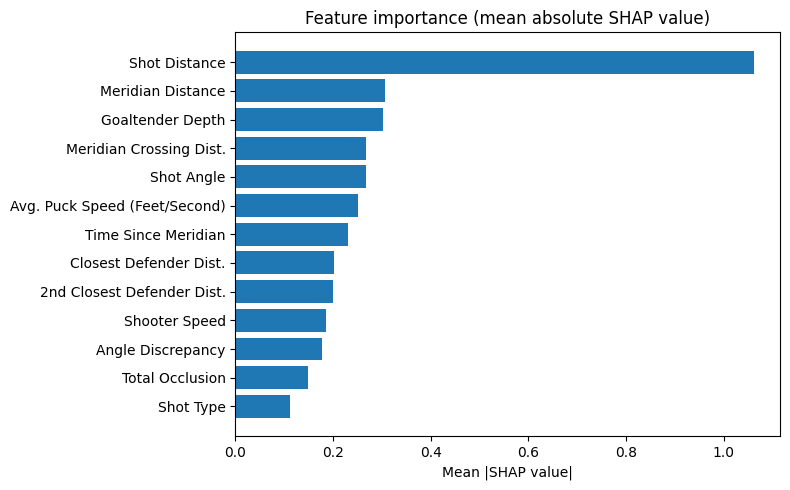

In [43]:
import matplotlib.pyplot as plt

FEATURE_LABELS = {
    "Shot_Angle": "Shot Angle",
    "d_m": "Meridian Distance",
    "shot_distance": "Shot Distance",
    "shooter_speed_fps": "Shooter Speed",
    "closest_def_dist": "Closest Defender Dist.",
    "second_closest_def_dist": "2nd Closest Defender Dist.",
    "time_since_meridian": "Time Since Meridian",
    "meridian_cross_dist": "Meridian Crossing Dist.",
    "avg_puck_speed_fps": "Avg. Puck Speed (Feet/Second)",
    "total_occlusion": "Total Occlusion",
    "angle_discrepancy": "Angle Discrepancy",
    "goaltender_depth": "Goaltender Depth",
    "Detail_1": "Shot Type",
}

shap_pd = shap_importance.to_pandas()
shap_pd["Label"] = shap_pd["Feature"].map(FEATURE_LABELS)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(shap_pd["Label"], shap_pd["Mean_Abs_SHAP"])
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Feature importance (mean absolute SHAP value)")
plt.tight_layout()
fig.savefig("shap_feature_importance.png", dpi=300)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plot_features = [f for f in shap_importance["Feature"].to_list() if f != "Detail_1"]

FEATURE_LABELS_UNITS = {
    "shot_distance": "Shot Distance (ft)",
    "d_m": "Meridian Distance (ft)",
    "goaltender_depth": "Goaltender Depth (ft)",
    "meridian_cross_dist": "Meridian Crossing Dist. (ft)",
    "Shot_Angle": "Shot Angle (deg.)",
    "avg_puck_speed_fps": "Avg. Puck Speed (ft/s)",
    "time_since_meridian": "Time Since Meridian (s)",
    "closest_def_dist": "Closest Defender Dist. (ft)",
    "second_closest_def_dist": "2nd Closest Defender Dist. (ft)",
    "shooter_speed_fps": "Shooter Speed (ft/s)",
    "angle_discrepancy": "Angle Discrepancy (deg.)",
    "total_occlusion": "Total Occlusion",
}

feat_idx = {f: i for i, f in enumerate(FEATURES)}

ncols = 3
nrows = 4
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 14))
axes_flat = axes.flatten()

for i, feat in enumerate(plot_features):
    ax = axes_flat[i]
    col_idx = feat_idx[feat]
    x_vals = X.iloc[:, col_idx].values.astype(float)
    y_vals = shap_values[:, col_idx]

    ax.scatter(x_vals, y_vals, s=2, alpha=0.5, color="#1f77b4")
    ax.set_xlabel(FEATURE_LABELS_UNITS.get(feat, feat))
    ax.set_ylabel("SHAP Value")
    ax.grid(True, alpha=0.3)

for j in range(len(plot_features), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
fig.savefig("shap_dependence_grid.png", dpi=300)
plt.show()

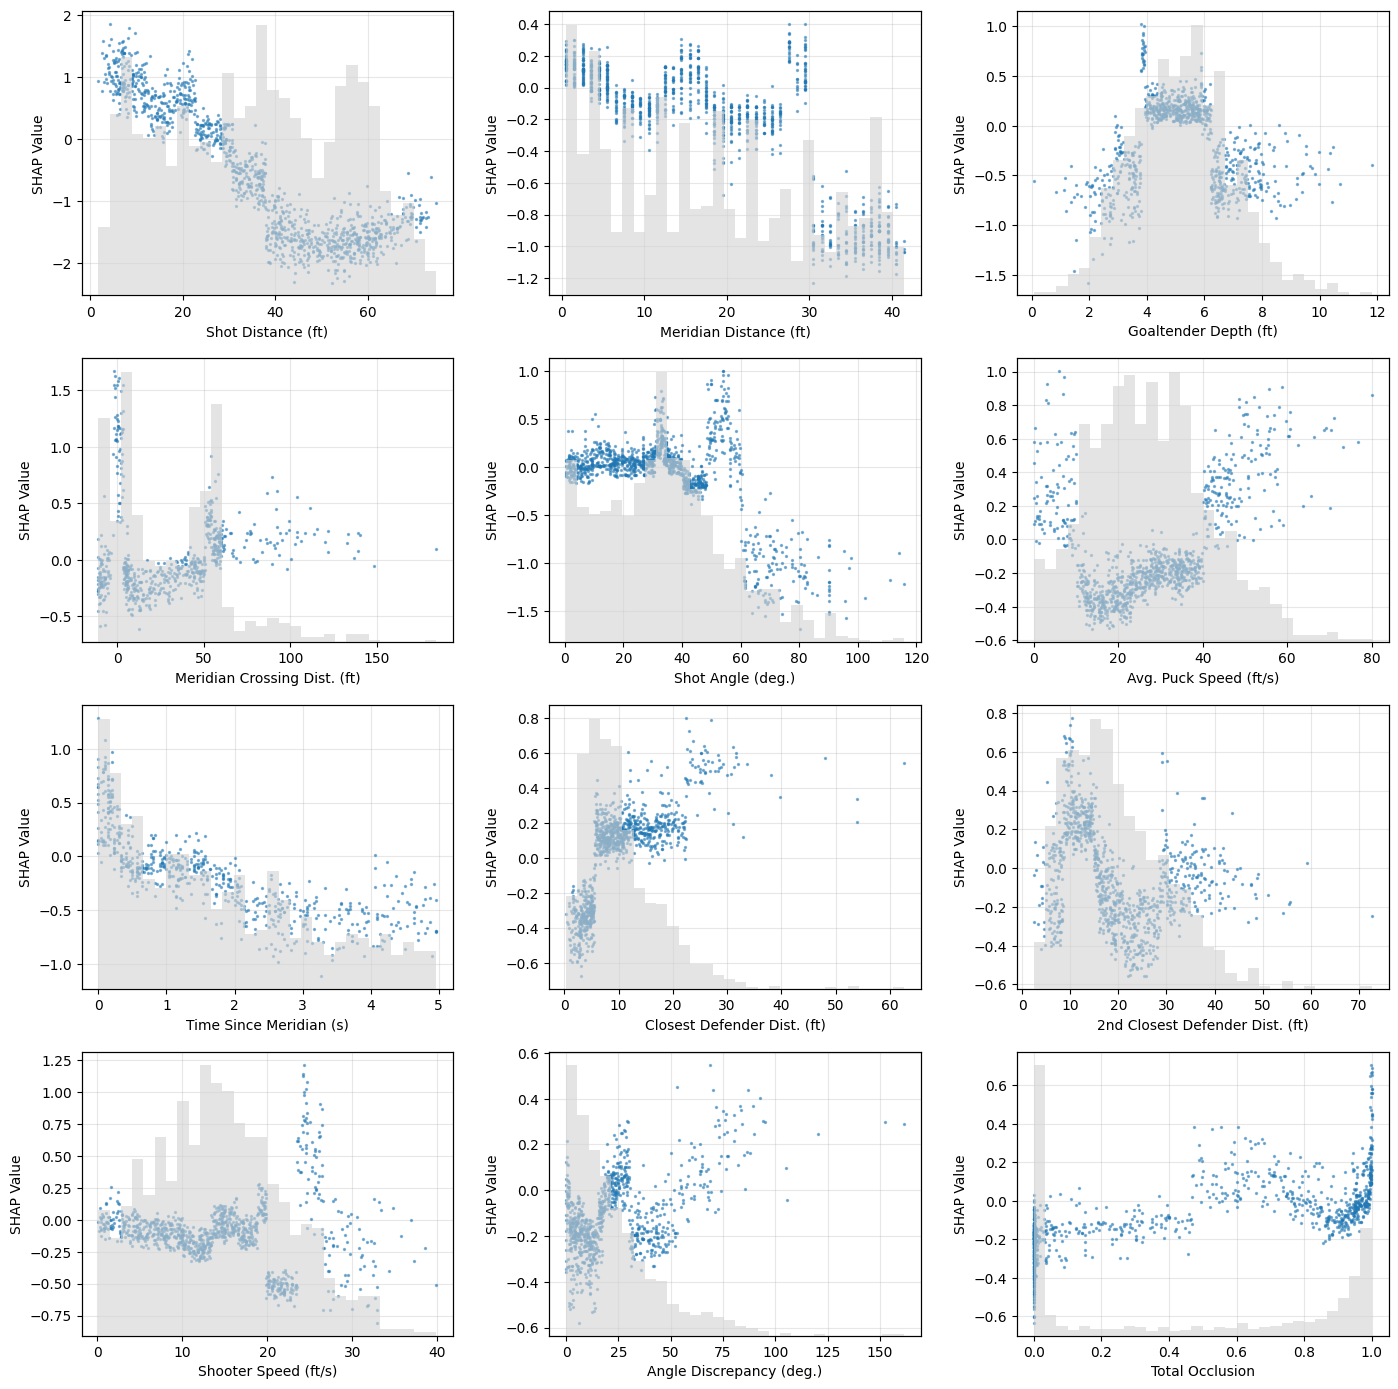

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Features to plot (excluding categorical Shot Type) sorted by importance
plot_features = [f for f in shap_importance["Feature"].to_list() if f != "Detail_1"]

FEATURE_LABELS_UNITS = {
    "shot_distance": "Shot Distance (ft)",
    "d_m": "Meridian Distance (ft)",
    "goaltender_depth": "Goaltender Depth (ft)",
    "meridian_cross_dist": "Meridian Crossing Dist. (ft)",
    "Shot_Angle": "Shot Angle (deg.)",
    "avg_puck_speed_fps": "Avg. Puck Speed (ft/s)",
    "time_since_meridian": "Time Since Meridian (s)",
    "closest_def_dist": "Closest Defender Dist. (ft)",
    "second_closest_def_dist": "2nd Closest Defender Dist. (ft)",
    "shooter_speed_fps": "Shooter Speed (ft/s)",
    "angle_discrepancy": "Angle Discrepancy (deg.)",
    "total_occlusion": "Total Occlusion",
}

# Map feature names to their column index in X / shap_values
feat_idx = {f: i for i, f in enumerate(FEATURES)}

ncols = 3
nrows = 4
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 14))
axes_flat = axes.flatten()

for i, feat in enumerate(plot_features):
    ax = axes_flat[i]
    col_idx = feat_idx[feat]
    x_vals = X.iloc[:, col_idx].values.astype(float)
    y_vals = shap_values[:, col_idx]

    # Background histogram
    ax2 = ax.twinx()
    ax2.hist(x_vals, bins=30, color="lightgray", edgecolor="none", alpha=0.6)
    ax2.set_yticks([])
    ax2.set_ylabel("")

    # SHAP scatter (on top)
    ax.scatter(x_vals, y_vals, s=2, alpha=0.5, color="#1f77b4", zorder=3)
    ax.set_xlabel(FEATURE_LABELS_UNITS.get(feat, feat))
    ax.set_ylabel("SHAP Value")
    ax.set_axisbelow(True)
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for j in range(len(plot_features), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
fig.savefig("shap_dependence_grid.png", dpi=300)
plt.show()